# Expansion of Sulphuric Acid by Freezing

This notebook plots figures for the derivative of specific volume of sulphuric acid with respect to temperature as a function of temperature and freezing extent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from typing import Tuple

from matplotlib.figure import Figure
from matplotlib.axes import Axes
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import FancyArrowPatch

from labellines import labelLines

In [2]:
import importlib

importlib.reload(matplotlib)

plt.rcdefaults()

## Physical Properties of Sulphuric Acid

In [3]:
DATA_FILE = "./SulfAcidProperties.csv"

data = pd.read_csv(DATA_FILE)

RHO_S = 0.917  # Density of Ice (kg/L)

## Basic Plots

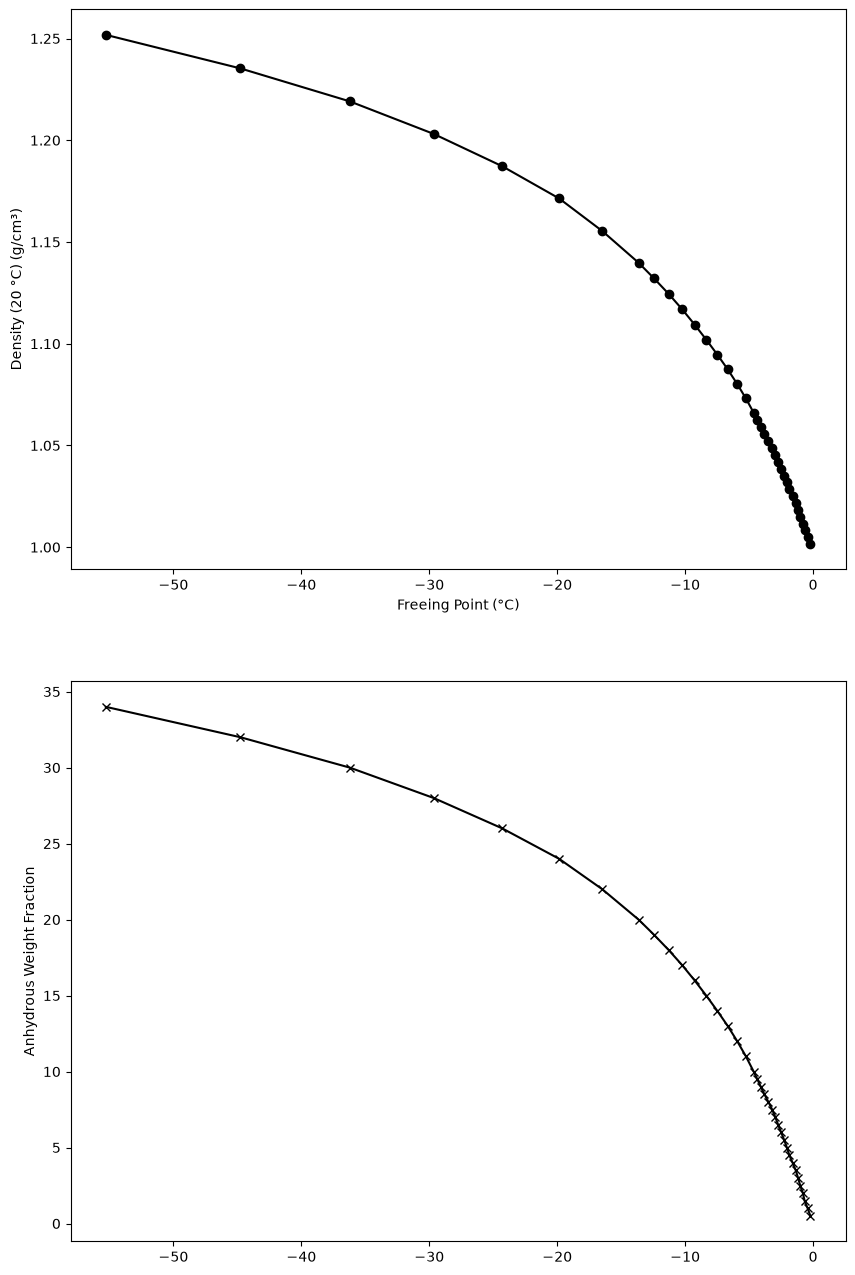

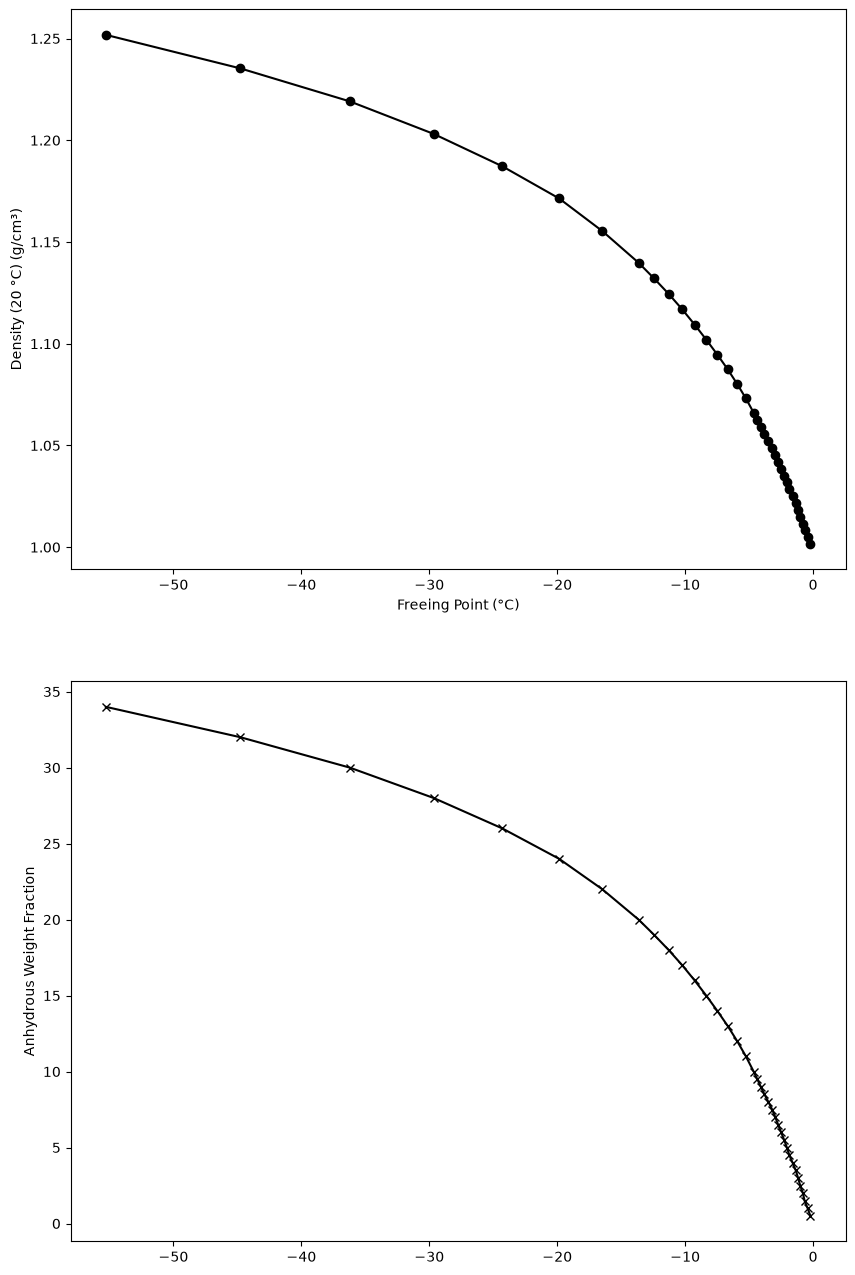

In [4]:
def plot_concentration_density(data) -> Figure:
    fig, ax = plt.subplots(2, 1, figsize=(10, 16))
    ax[0].plot(
        data["Freeing Point"],
        data["Density (20 °C)"],
        marker="o",
        linestyle="-",
        color="black",
    )

    ax[0].set_xlabel("Freeing Point (°C)")
    ax[0].set_ylabel("Density (20 °C) (g/cm³)")

    ax[1].plot(
        data["Freeing Point"],
        data["Anhydrous Weight Fraction"],
        marker="x",
        linestyle="-",
        color="black",
    )

    ax[1].set_ylabel("Anhydrous Weight Fraction")

    return fig


plot_concentration_density(data)

## Numerical Derivative of Density and Concentration with respect to Freezing Point

In [5]:
def calculate_derivatives(data: pd.DataFrame) -> pd.DataFrame:
    data["Density Derivative"] = np.gradient(
        data["Density (20 °C)"], data["Freeing Point"]
    )
    data["Concentration Derivative"] = np.gradient(
        data["Anhydrous Weight Fraction"], data["Freeing Point"]
    )
    return data


data_with_derivatives = calculate_derivatives(data)

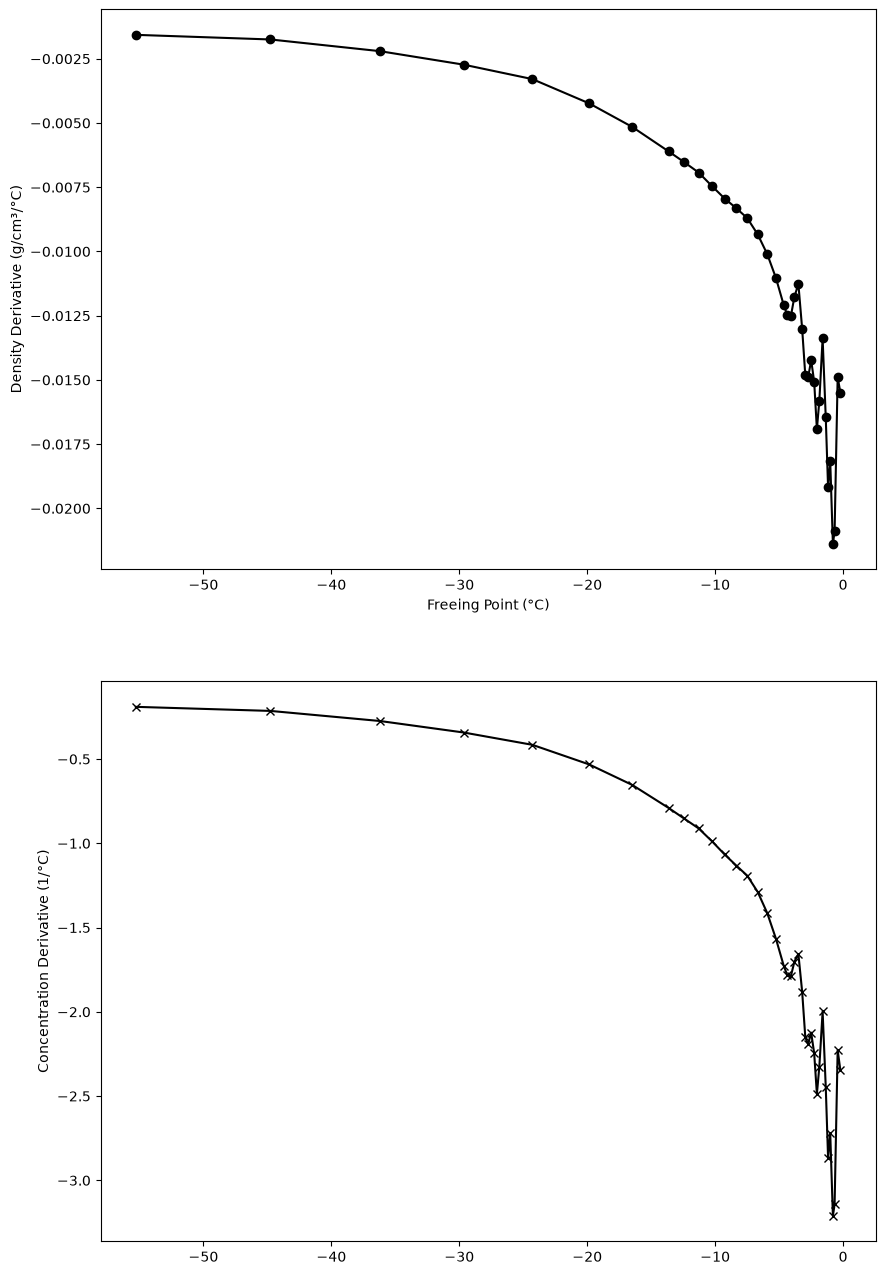

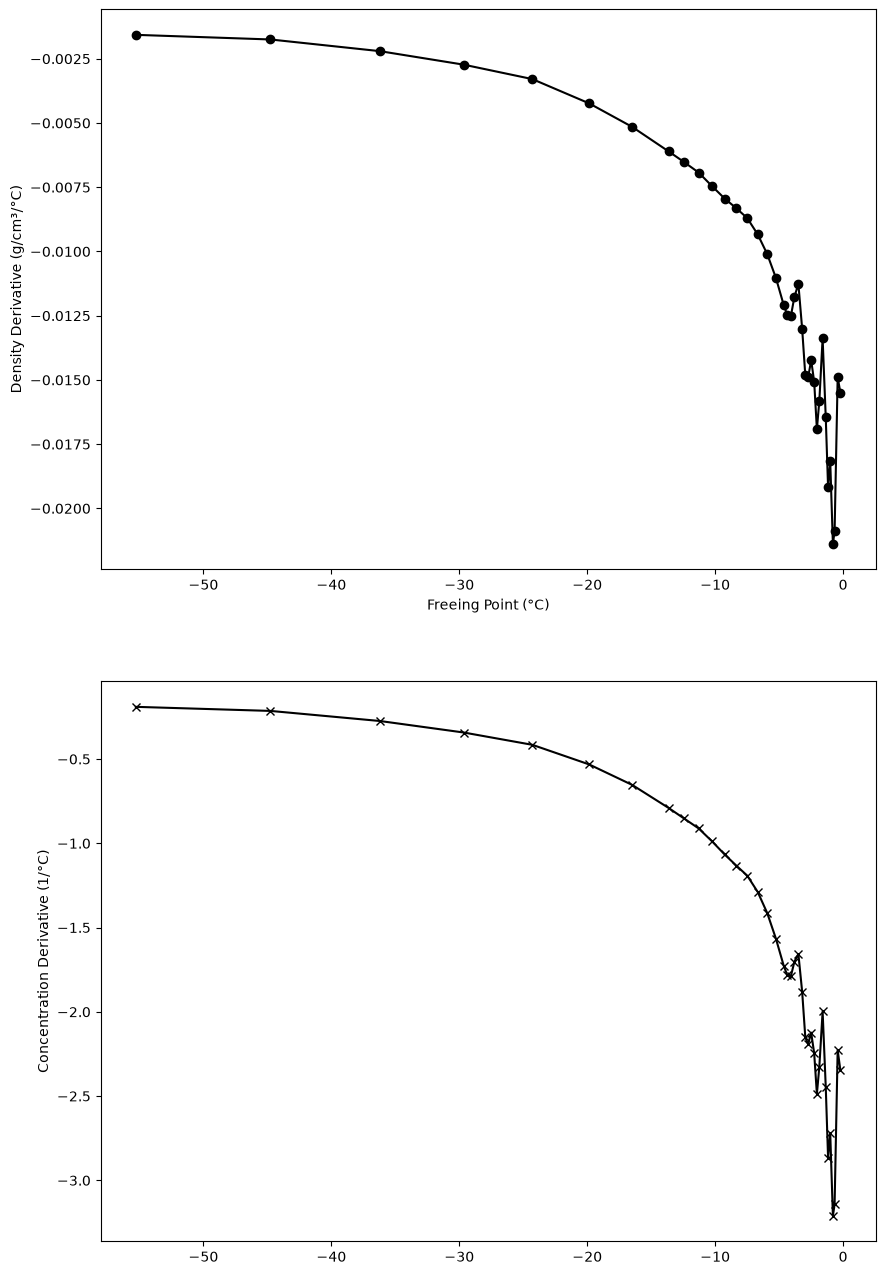

In [6]:
def plot_derivatives_vs_temperature(data: pd.DataFrame) -> Figure:
    fig, ax = plt.subplots(2, 1, figsize=(10, 16))
    ax[0].plot(
        data["Freeing Point"],
        data["Density Derivative"],
        marker="o",
        linestyle="-",
        color="black",
    )

    ax[0].set_xlabel("Freeing Point (°C)")
    ax[0].set_ylabel("Density Derivative (g/cm³/°C)")

    ax[1].plot(
        data["Freeing Point"],
        data["Concentration Derivative"],
        marker="x",
        linestyle="-",
        color="black",
    )

    ax[1].set_ylabel("Concentration Derivative (1/°C)")

    return fig


plot_derivatives_vs_temperature(data_with_derivatives)

In [7]:
def specific_volume_derivative(
    data_with_derivatives: pd.DataFrame, F: float
) -> pd.Series:
    """
    Computes the specific volume derivative with respect to temperature for all points of 'Freezing Point' in data_with_derivatives, given a specific freezing extent F

    Parameters:
    - data_with_derivatives: pd.DataFrame containing the columns 'Density (20 °C)', 'Density Derivative', and 'Concentration Derivative'
    - F: float, the freezing extent (0 <= F <= 1 - 1 / A_E(T))

    Returns:
    - pd.Series containing the specific volume derivative with respect to temperature for each 'Freezing Point', less points not physically possible (i.e., where F > 1 - 1 / A_E(T))
    """

    def d_nu_dT(
        A_E: float, d_A_E_dT: float, rho_L: float, d_rho_L_dT: float, F: float
    ) -> float:
        """
        Computes the specific volume derivative with respect to temperature.

        Parameters:
        - A_E: float, the anhydrous weight fraction at a given temperature
        - d_A_E_dT: float, the derivative of the anhydrous weight fraction with respect to the freezing point temperature
        - rho_L: float, the density of liquid sulphuric acid (g/cm³) at the freezing point temperature (or approximated by the density at 20 °C)
        - d_rho_L_dT: float, the derivative of the density of liquid sulphuric acid with respect to the freezing point temperature
        - F: float, the freezing extent (0 <= F <= 1 - 1 / A_E)

        Returns:
        - float, the specific volume derivative with respect to temperature
        """
        RHO_S = 0.917  # Density of Ice (kg/L)
        d_nu_dT_value = (1 - F) * (
            (1 / A_E) * d_A_E_dT * ((1 / RHO_S) - (1 / rho_L))
            + (1 / rho_L**2) * d_rho_L_dT
        )
        return d_nu_dT_value

    # Calculate the specific volume derivative for each row in the DataFrame
    specific_volume_derivative_series = data_with_derivatives.apply(
        lambda row: (
            d_nu_dT(
                A_E=row["Anhydrous Weight Fraction"],
                d_A_E_dT=row["Concentration Derivative"],
                rho_L=row["Density (20 °C)"],
                d_rho_L_dT=row["Density Derivative"],
                F=F,
            )
            if F <= 1 - 1 / row["Anhydrous Weight Fraction"]
            else np.nan
        ),  # Assign NaN for physically impossible points
        axis=1,
    )
    return specific_volume_derivative_series

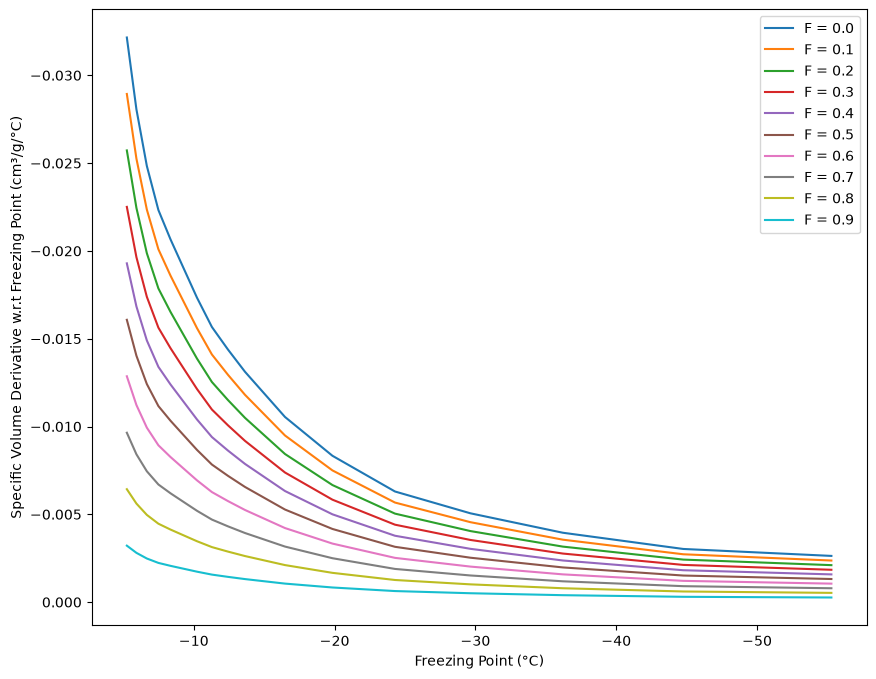

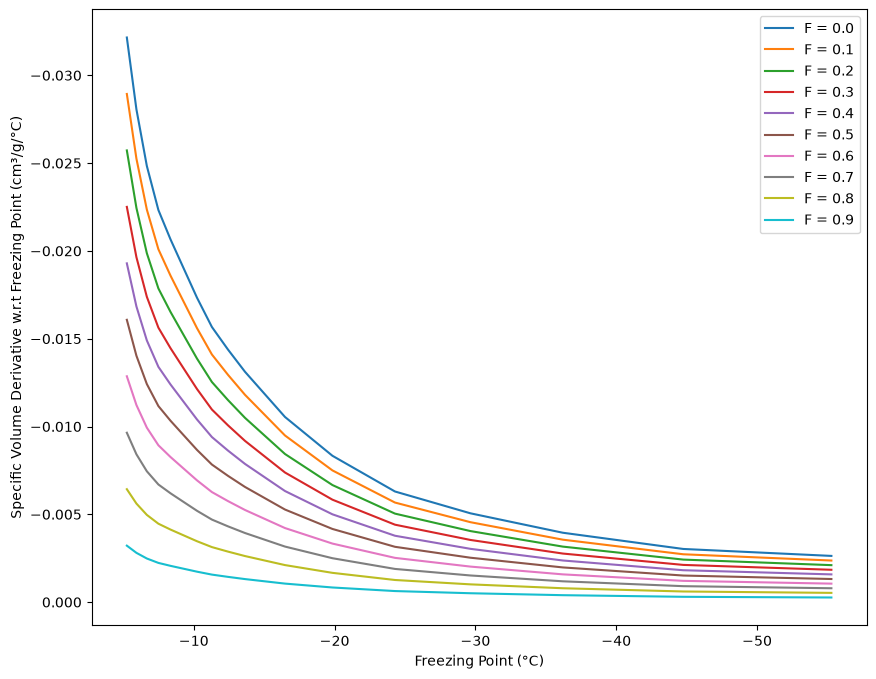

In [8]:
def plot_specific_volume_derivative_vs_temperature(
    data_with_derivatives: pd.DataFrame,
) -> Figure:
    """
    Plots the specific volume derivative with respect to temperature as a function of freezing point temperature for a range of freezing extents F.

    Parameters:
    - data_with_derivatives: pd.DataFrame containing the columns 'Freezing Point', 'Density (20 °C)', 'Density Derivative', 'Anhydrous Weight Fraction', and 'Concentration Derivative'
    - F: float, the freezing extent

    Returns:
    - matplotlib.figure.Figure object containing the plot
    """

    freezing_extents = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    CROP_UPPER_LIMIT = (
        -5.0
    )  # Crop the x-axis (Freezing Point) due to noise in the derivative data

    fig, ax = plt.subplots(figsize=(10, 8))

    for F in freezing_extents:
        specific_volume_derivative_series = specific_volume_derivative(
            data_with_derivatives, F
        )

        # Don't include points where the numerical derivative is noisy
        specific_volume_derivative_series = specific_volume_derivative_series[
            data_with_derivatives["Freeing Point"] <= CROP_UPPER_LIMIT
        ]
        freezing_point_series = data_with_derivatives["Freeing Point"][
            data_with_derivatives["Freeing Point"] <= CROP_UPPER_LIMIT
        ]

        ax.plot(
            freezing_point_series,
            specific_volume_derivative_series,
            label=f"F = {F}",
        )

    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.set_xlabel("Freezing Point (°C)")
    ax.set_ylabel("Specific Volume Derivative w.r.t Freezing Point (cm³/g/°C)")
    ax.legend()

    return fig


plot_specific_volume_derivative_vs_temperature(data_with_derivatives)

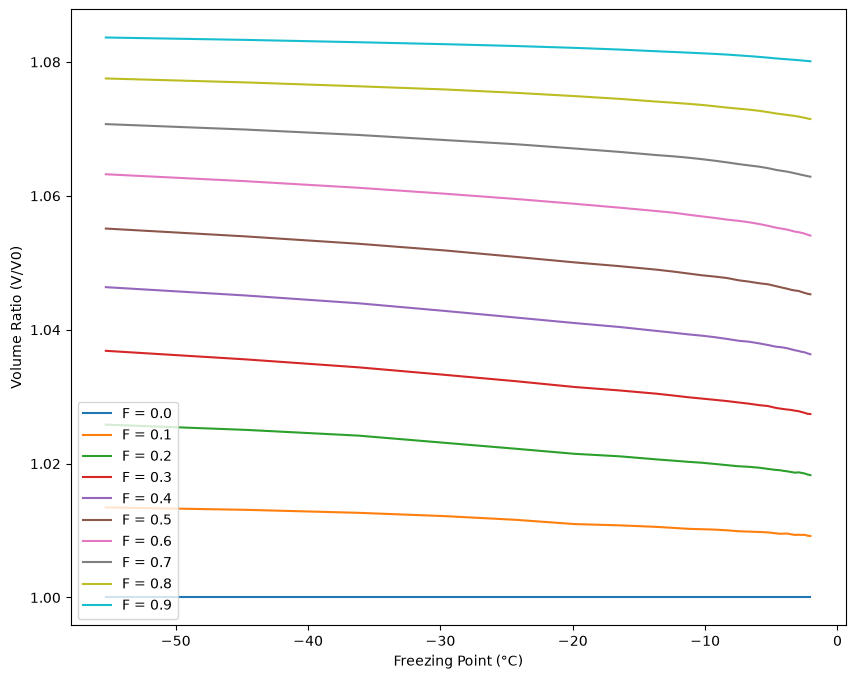

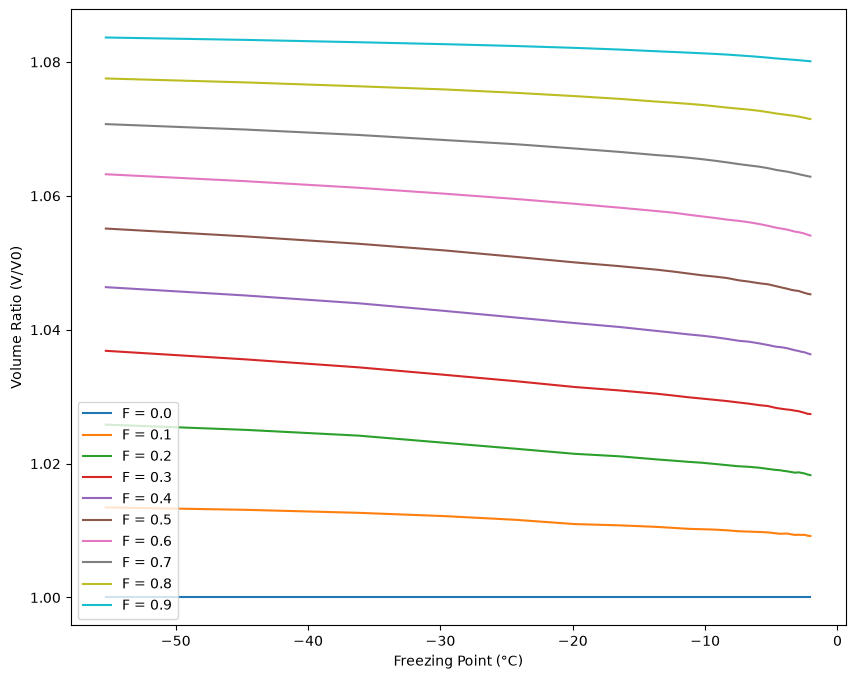

In [9]:
def plot_volume_ratio_over_temperature(data_with_derivatives: pd.DataFrame) -> Figure:
    """
    Plots the volume ratio (V/V0) as a function of freezing point temperature for a range of freezing extents F.

    """

    fig, ax = plt.subplots(figsize=(10, 8))

    freezing_extents = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    for F in freezing_extents:
        V = (1 - F) / data_with_derivatives["Density (20 °C)"] + F / RHO_S
        A_0 = (1 - F) * data_with_derivatives["Anhydrous Weight Fraction"]
        # Interpolate the density given the anhydrous weight fraction to find the original density before freezing
        rho_0 = np.interp(
            A_0,
            data_with_derivatives["Anhydrous Weight Fraction"],
            data_with_derivatives["Density (20 °C)"],
        )
        V_0 = 1 / rho_0
        volume_ratio = V / V_0

        # Filter points > -1°C (interpolation errors)
        volume_ratio = volume_ratio[data_with_derivatives["Freeing Point"] <= -2]
        freezing_point_series = data_with_derivatives["Freeing Point"][
            data_with_derivatives["Freeing Point"] <= -2
        ]

        ax.plot(
            freezing_point_series,
            volume_ratio,
            label=f"F = {F}",
        )

    ax.set_xlabel("Freezing Point (°C)")
    ax.set_ylabel("Volume Ratio (V/V0)")
    ax.legend()

    return fig


plot_volume_ratio_over_temperature(data_with_derivatives)

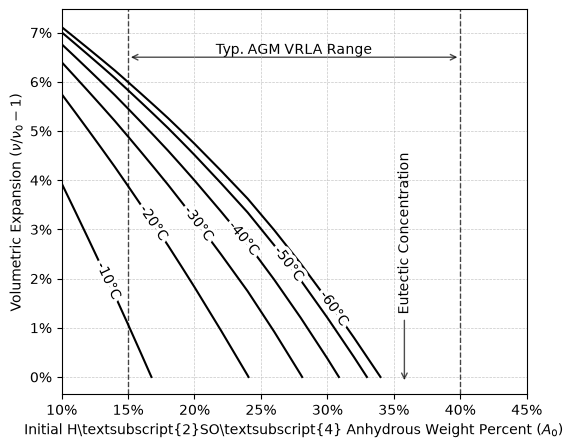

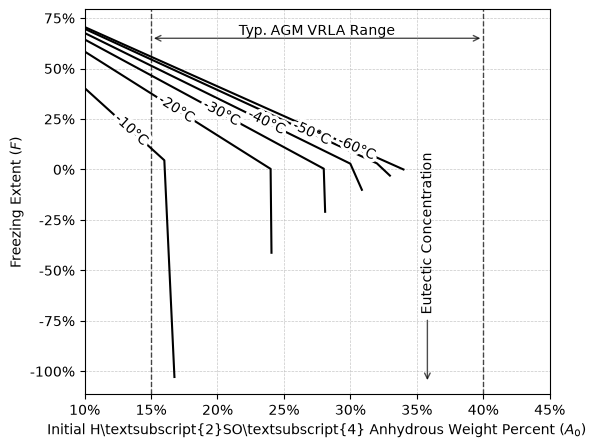

In [10]:
def plot_volume_ratio_over_initial_concentration(
    data_with_derivatives: pd.DataFrame,
) -> Tuple[Figure, Figure]:
    """
    Plots the volume ratio (V/V0) as a function of initial concentration (Anhydrous Weight Fraction) for a range of freezing extents F.

    """

    fig1, ax1 = plt.subplots(figsize=(6, 5))
    fig2, ax2 = plt.subplots(figsize=(6, 5))

    isotherms = [-10, -20, -30, -40, -50, -60]

    A_0 = data_with_derivatives["Anhydrous Weight Fraction"]

    for T_fus in isotherms:
        a_E = np.interp(
            T_fus,
            data_with_derivatives["Freeing Point"][
                ::-1
            ],  # Reverse the order for interpolation
            data_with_derivatives["Anhydrous Weight Fraction"][::-1],
        )

        f = 1 - A_0 / a_E

        v_0 = 1 / data_with_derivatives["Density (20 °C)"]
        rho_L = np.interp(
            T_fus,
            data_with_derivatives["Freeing Point"][::-1],
            data_with_derivatives["Density (20 °C)"][::-1],
        )
        v_F = (1 - f) / rho_L + f / RHO_S

        volume_ratio = v_F / v_0

        # Interpolated limit points for 1:1 volume ratio and 0% freezing extent cutoffs
        A_0_limit = np.interp(
            1.0,
            volume_ratio[::-1],
            A_0[::-1],
        )
        f_limit = np.interp(
            0.0,
            volume_ratio[::-1],
            f[::-1],
        )

        # Filter points where F is physically impossible (i.e., where F > 0)
        A_0_valid = A_0[f >= 0]
        volume_ratio = volume_ratio[f >= 0]
        f = f[f >= 0]

        # Add the interpolated points to the filtered arrays
        A_0_valid = np.append(A_0_valid, A_0_limit)
        volume_ratio = np.append(volume_ratio, 1.0)
        f = np.append(f, f_limit)

        # Filter to operating range of AGM VRLA batteries (over 10% anhydrous weight fraction)
        volume_ratio = volume_ratio[(A_0_valid >= 10) & (A_0_valid <= 50)]
        f = f[(A_0_valid >= 10) & (A_0_valid <= 50)]
        A_0_valid = A_0_valid[(A_0_valid >= 10) & (A_0_valid <= 50)]

        ax1.plot(
            A_0_valid,
            volume_ratio,
            label=f"{T_fus}°C",
            color="black",
        )

        ax2.plot(
            A_0_valid,
            f,
            label=f"{T_fus}°C",
            color="black",
        )

    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x-1:.0%}"))
    ax1.set_ylabel(r"Volumetric Expansion ($\nu/\nu_0 - 1$)")

    ax2.set_ylabel(r"Freezing Extent ($F$)")
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))

    for ax in [ax1, ax2]:
        ax.set_xlabel(
            r"Initial H\textsubscript{2}SO\textsubscript{4} Anhydrous Weight Percent ($A_0$)"
        )
        ax.grid(linestyle="--", linewidth=0.5, alpha=0.7)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/100:.0%}"))
        labelLines(ax.get_lines())
        ax.set_xlim(10, 45)
        ax.axvline(x=15, color="black", linestyle="--", linewidth=1, alpha=0.7)
        ax.axvline(x=40, color="black", linestyle="--", linewidth=1, alpha=0.7)
        agm_rang_patch = FancyArrowPatch(
            (15, 0.65 if ax == ax2 else 1.065),
            (40, 0.65 if ax == ax2 else 1.065),
            arrowstyle="<->",
            color="black",
            linewidth=1,
            mutation_scale=10,
            alpha=0.7,
        )
        range_patch = ax.add_patch(agm_rang_patch)
        ax.annotate(
            "Typ. AGM VRLA Range",
            xycoords=range_patch,
            xy=(0.5, 0.5),
            ha="center",
            va="bottom",
        )

        eutectic_arrow_patch = FancyArrowPatch(
            (35.8, ax.get_ylim()[0] + 0.03 * (ax.get_ylim()[1] - ax.get_ylim()[0])),
            (35.8, ax.get_ylim()[0] + 0.20 * (ax.get_ylim()[1] - ax.get_ylim()[0])),
            arrowstyle="<-",
            color="black",
            linewidth=1,
            mutation_scale=10,
            alpha=0.7,
        )
        ax.add_patch(eutectic_arrow_patch)
        ax.annotate(
            "Eutectic Concentration",
            xycoords=eutectic_arrow_patch,
            xy=(0.5, 1.1),
            ha="center",
            va="bottom",
            rotation=90,
        )

    return fig1, fig2


volume_expansion_fig, freezing_extent_fig = (
    plot_volume_ratio_over_initial_concentration(data_with_derivatives)
)

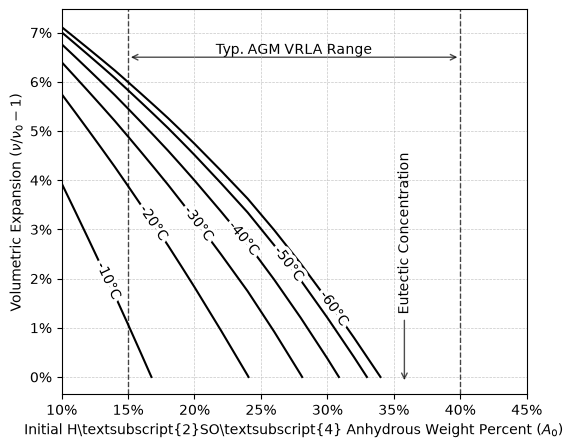

In [11]:
volume_expansion_fig

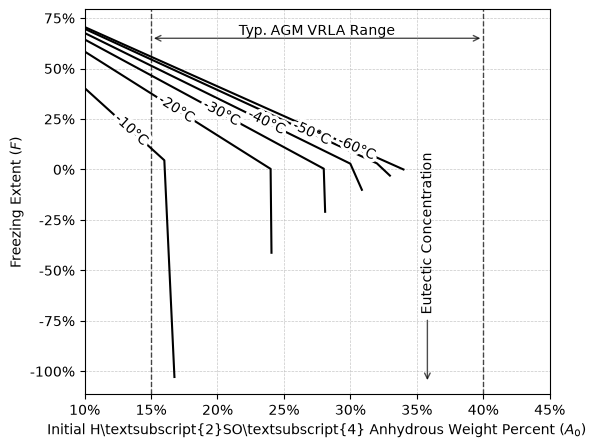

In [12]:
freezing_extent_fig

## Simulated Pressure Change with Temperature and Freezing Volumetric Expansion

In [13]:
def volume_ratio(
    A_0: float,
    T: float,
    data_with_derivatives: pd.DataFrame,
) -> float:
    """
    Calculates the volume ratio (V/V0) for a given initial anhydrous weight fraction A_0 and temperature T.

    Parameters:
    - A_0: float, the initial anhydrous weight fraction
    - T: float, the temperature (°C)
    - data_with_derivatives: pd.DataFrame containing the columns 'Freezing Point', 'Density (20 °C)', 'Density Derivative', 'Anhydrous Weight Fraction', and 'Concentration Derivative'

    Returns:
    - float, the volume ratio (V/V0)
    """
    fus_T_0 = np.interp(
        A_0 * 100,
        data_with_derivatives["Anhydrous Weight Fraction"],
        data_with_derivatives["Freeing Point"],
    )

    if T > fus_T_0:
        return 1.0  # No freezing occurs above the initial freezing point

    a_E = (
        np.interp(
            T,
            data_with_derivatives["Freeing Point"][::-1],
            data_with_derivatives["Anhydrous Weight Fraction"][::-1],
        )
        / 100
    )

    f = 1 - A_0 / a_E

    v_0 = 1 / np.interp(
        A_0 * 100,
        data_with_derivatives["Anhydrous Weight Fraction"],
        data_with_derivatives["Density (20 °C)"],
    )  # Initial specific volume before freezing

    rho_L = np.interp(
        T,
        data_with_derivatives["Freeing Point"][::-1],
        data_with_derivatives["Density (20 °C)"][::-1],
    )  # Density of liquid sulphuric acid at temperature T

    v_F = (1 - f) / rho_L + f / RHO_S  # Specific volume after freezing

    volume_ratio = v_F / v_0

    return volume_ratio


def isomolar_pressure_ratio(
    T_0: float,
    T_1: float,
    V_0: float,
    V_1: float,
) -> float:
    """
    Calculates the proportional isomolar pressure change (P_1/P_0) due to a change in temperature and volume, assuming ideal gas behaviour.
    """
    ABSOLUTE_ZERO_C = -273.15  # Absolute zero in Celsius
    return (V_0 / V_1) * (T_1 - ABSOLUTE_ZERO_C) / (T_0 - ABSOLUTE_ZERO_C)

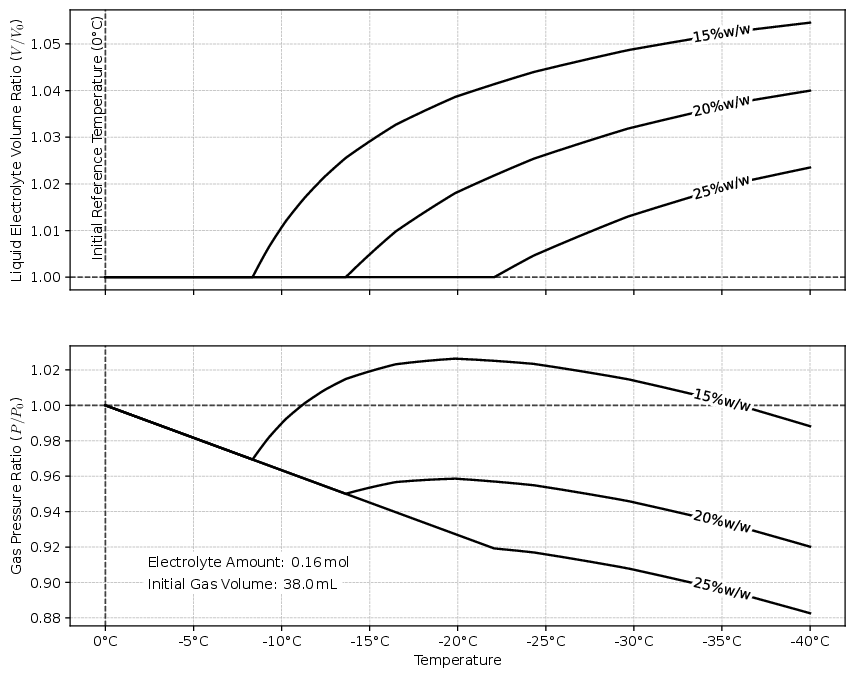

In [32]:
def plot_isomolar_pressure_ratio(
    data_with_derivatives: pd.DataFrame,
    electrolyte_amount: float,
    initial_gas_volume: float,
    lower_T: float = -40,
    initial_T: float = 20,
) -> Figure:
    """
    Calculates the proportional isomolar pressure change (P_1/P_0) in a lead-acid battery cell due to freezing of the electrolyte and temperature change, assuming isomolar conditions.

    Parameters:
    - data_with_derivatives: pd.DataFrame containing the columns 'Freezing Point', 'Density (20 °C)', 'Density Derivative', 'Anhydrous Weight Fraction', and 'Concentration Derivative'
    - initial_T: float, the initial temperature (°C)
    - lower_T: float, the lower temperature (°C)
    - electrolyte_amount: float, the amount of electrolyte in the cell (kg)
    - cell_volume: float, the total volume of the cell (m³)
    - cell_initial_gas_volume: float, the initial volume of gas in the cell (m³)
    - Returns:
    - Figure, the plot of the pressure change over temperature

    Assumes ideal gas behaviour.
    """
    RANGE_T = np.linspace(initial_T, lower_T, 1000)

    RANGE_A = np.arange(
        0.15, 0.26, 0.05
    )  # Initial anhydrous weight fraction range for plotting

    SULPHURIC_ACID_MOLAR_MASS = 98.079  # g/mol

    fig, ax = plt.subplots(
        2,
        1,
        figsize=(10, 8),
        sharex=True,
    )

    for a_0 in RANGE_A:
        # Solve for initial electrolyte volume
        electrolyte_density_0 = np.interp(
            a_0 * 100,
            data_with_derivatives["Anhydrous Weight Fraction"],
            data_with_derivatives["Density (20 °C)"],
        )  # kg/L = g/cm³

        electrolyte_concentration_0 = (
            electrolyte_density_0 * a_0 / SULPHURIC_ACID_MOLAR_MASS * 1000
        )  # kg/L / (g/mol) * (1000/k) = mol/L

        electrolyte_volume_0 = (
            electrolyte_amount / electrolyte_concentration_0
        )  # mol / (mol/L) = L

        volume_ratio_over_temperature = [
            volume_ratio(a_0, T, data_with_derivatives) for T in RANGE_T
        ]

        ax[0].plot(
            RANGE_T,
            volume_ratio_over_temperature,
            color="black",
            label=f"{a_0:.0%}w/w",
        )

        gas_volumes_over_temperature = [
            initial_gas_volume - electrolyte_volume_0 * (ratio - 1)
            for ratio in volume_ratio_over_temperature
        ]

        temperature_and_volume_pairs = zip(RANGE_T, gas_volumes_over_temperature)

        pressure_change_over_temperature = [
            isomolar_pressure_ratio(
                initial_T,
                T,
                initial_gas_volume,
                volume,
            )
            for T, volume in temperature_and_volume_pairs
        ]

        ax[1].plot(
            RANGE_T,
            pressure_change_over_temperature,
            color="black",
            label=f"{a_0:.0%}w/w",
        )

    left_label_x = lower_T + 5

    for axis in [ax[0], ax[1]]:
        axis.axhline(y=1, color="black", linestyle="--", linewidth=1, alpha=0.7)
        axis.axvline(x=initial_T, color="black", linestyle="--", linewidth=1, alpha=0.7)

        labelLines(
            axis.get_lines(),
            xvals=[left_label_x] * len(axis.get_lines()),
        )

    ax[0].invert_xaxis()

    ax[0].text(
        initial_T,
        1.03,
        f"Initial Reference Temperature ({initial_T}°C)",
        color="black",
        rotation=90,
        fontsize=10,
        ha="right",
        va="center",
    )

    ax[0].set_ylabel("Liquid Electrolyte Volume Ratio ($V / V_0$)")
    ax[1].set_ylabel("Gas Pressure Ratio ($P / P_0$)")

    ax[1].set_xlabel("Temperature")
    ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}°C"))

    ax[0].grid(linestyle="--", linewidth=0.5, alpha=0.7)
    ax[1].grid(linestyle="--", linewidth=0.5, alpha=0.7)

    # Print info of other parameters on top axis
    text_params = {
        "ha": "left",
        "va": "bottom",
        "fontsize": 10,
        "color": "black",
        "bbox": dict(boxstyle="round", facecolor="white", edgecolor="none"),
    }
    ax[1].text(
        0.1,
        0.20,
        rf"Electrolyte Amount: {electrolyte_amount}\,mol",
        transform=ax[1].transAxes,
        **text_params,
    )
    ax[1].text(
        0.1,
        0.13,
        rf"Initial Gas Volume: {initial_gas_volume*1000}\,mL",
        transform=ax[1].transAxes,
        **text_params,
    )

    return fig


plot_isomolar_pressure_ratio(
    data_with_derivatives,
    initial_gas_volume=38.0 / 1000,  # L
    electrolyte_amount=0.16,  # mol
    initial_T=0,
)

## PGF Export

In [33]:
import os
from cycler import cycler

COLORBLIND_COLORS = [
    "#377eb8",
    "#ff7f00",
    "#4daf4a",
    "#f781bf",
    "#a65628",
    "#984ea3",
    "#999999",
    "#e41a1c",
    "#dede00",
    "#000000",
]

importlib.reload(matplotlib)

plt.rcParams.update(matplotlib.rcParamsDefault)

matplotlib.use("pgf")

color_cycle = cycler(color=COLORBLIND_COLORS)

plt.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "axes.prop_cycle": color_cycle,
    }
)

PGF_EXPORT_DIR = "../Plots/Latex"
os.makedirs(PGF_EXPORT_DIR, exist_ok=True)

In [34]:
volume_expansion_fig_pgf, _ = plot_volume_ratio_over_initial_concentration(
    data_with_derivatives
)

volume_expansion_fig_pgf.savefig(
    os.path.join(PGF_EXPORT_DIR, "Volume-Expansion.pgf"),
    bbox_inches="tight",
)

os.rename(
    os.path.join(PGF_EXPORT_DIR, "Volume-Expansion.pgf"),
    os.path.join(PGF_EXPORT_DIR, "Volume-Expansion.tex"),
)

In [35]:
gas_liquid_ratio_fig_pgf = plot_isomolar_pressure_ratio(
    data_with_derivatives,
    initial_gas_volume=38.0 / 1000,  # L
    electrolyte_amount=0.16,  # mol
    initial_T=0,
)

gas_liquid_ratio_fig_pgf.savefig(
    os.path.join(PGF_EXPORT_DIR, "Gas-Liquid-Ratio.pgf"),
    bbox_inches="tight",
)

os.rename(
    os.path.join(PGF_EXPORT_DIR, "Gas-Liquid-Ratio.pgf"),
    os.path.join(PGF_EXPORT_DIR, "Gas-Liquid-Ratio.tex"),
)

/var/folders/3f/ct0r54cd0497vnq7h8jk96q40000gp/T/ipykernel_84033/989137572.py:31: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(
/Users/lawrence/GitHub/SISPS-PUB-SOH/SISPS-EXP-SOH/Notebook/.conda/lib/python3.11/site-packages/labellines/core.py:181: UserWarning: Tried to label line Line2D(_child3), but could not find a label for it.
  warnings.warn(
/Users/lawrence/GitHub/SISPS-PUB-SOH/SISPS-EXP-SOH/Notebook/.conda/lib/python3.11/site-packages/labellines/core.py:181: UserWarning: Tried to label line Line2D(_child4), but could not find a label for it.
  warnings.warn(
